# Chapter 4 Lab: Point-in-Time RAG for Fictional Filings

**Runtime:** 3–4 minutes · **Difficulty:** intermediate · **Credentials:** none

This lab builds and evaluates a complete retrieval layer: document contracts, metadata
filters, BM25, hybrid retrieval, ranking metrics, time gates, claim support, and an audit
fingerprint. Generation is deliberately replaced by an inspectable claim template so the
retrieval contract remains the focus.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/04_point_in_time_rag.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/04_point_in_time_rag.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- index filing sections with stable document identifiers;
- enforce `available_at <= decision_time` before retrieval;
- compare lexical and hybrid retrieval with Recall, MRR, and nDCG;
- evaluate material claims against evidence; and
- distinguish retrieval quality from answer faithfulness.


In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import Claim, Document, EvidenceBundle, canonical_hash, seed_everything
from finllm_lab.metrics import (
    proportion_interval,
    release_score,
    retrieval_metrics,
    retrieval_metrics_with_intervals,
)
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.rag import BM25Index, faithfulness_score
from finllm_lab.temporal import TemporalLeakageError, assert_documents_available

set_finance_theme()
rng = seed_everything(404)

records = [json.loads(line) for line in (ROOT / "data" / "filings.jsonl").read_text().splitlines()]
documents = tuple(
    Document(
        document_id=row["document_id"],
        text=row["text"],
        source=row["source"],
        available_at=pd.Timestamp(row["available_at"]).to_pydatetime(),
        issuer=row["ticker"],
        section=row["section"],
        metadata={"period": row["period"], "form": row["form"]},
    )
    for row in records
)
questions = json.loads((ROOT / "data" / "rag_questions.json").read_text())
issuer_names = {row["ticker"]: row["issuer"] for row in records}
pd.DataFrame(
    {
        "documents": [len(documents)],
        "issuers": [len({d.issuer for d in documents})],
        "sections": [len({d.section for d in documents})],
        "benchmark_questions": [len(questions)],
    }
)


,documents,issuers,sections,benchmark_questions
0,208,4,4,16


## 1. Lexical retrieval with time and issuer filters


In [3]:
index = BM25Index(documents)
example = questions[0]
example_results = index.search(
    example["query"],
    k=5,
    decision_time=pd.Timestamp(example["decision_time"]).to_pydatetime(),
    issuer=example["ticker"],
    period=example["relevant_document_ids"][0].split("-")[2],
)
pd.DataFrame(
    [
        {
            "rank": rank,
            "document_id": item.document_id,
            "score": item.score,
            "available_at": item.available_at,
            "preview": item.passage[:95] + "…",
        }
        for rank, item in enumerate(example_results, 1)
    ]
)


,rank,document_id,score,available_at,preview
0,1,filing-ACME-2025Q4-results,1.000000,2026-02-05 13:20:00+00:00,"For 2025Q4, Acme Cloud Systems recorded revenue of $2,333.0 million, representing 6.6% year-ove…"
1,2,filing-ACME-2025Q4-risk_factors,0.154187,2026-02-05 13:20:00+00:00,"Key risks include cloud price competition, data-center capacity, cyber incidents, and customer …"
2,3,filing-ACME-2025Q4-guidance,0.065924,2026-02-05 13:20:00+00:00,Management changed full-year revenue guidance by +1.0% and said the range remains sensitive to …
3,4,filing-ACME-2025Q4-liquidity,0.054233,2026-02-05 13:20:00+00:00,"Quarter-end cash was $417.6 million and gross debt was $1,601.0 million. Net leverage was 2.13x…"


## 2. Evaluate BM25 and a hybrid retriever

The hybrid score combines normalized BM25 with TF–IDF cosine similarity. Both systems
receive the same point-in-time, issuer, and period filters. Because the issuer is already
fixed by metadata, it is removed from the ranking query so its repeated name does not
overwhelm section terms such as `leverage`, `risks`, or `guidance`.


In [4]:
def normalize(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    span = values.max() - values.min()
    return (values - values.min()) / span if span > 0 else np.zeros_like(values)

def normalized_query(question: dict) -> str:
    period = question["relevant_document_ids"][0].split("-")[2]
    return (
        question["query"]
        .replace(issuer_names[question["ticker"]], "")
        .replace(period, "")
    )

def admissible_subset(question: dict) -> tuple[Document, ...]:
    decision = pd.Timestamp(question["decision_time"]).to_pydatetime()
    period = question["relevant_document_ids"][0].split("-")[2]
    return tuple(
        d
        for d in documents
        if d.issuer == question["ticker"]
        and d.metadata["period"] == period
        and d.available_at <= decision
    )

def hybrid_rank(question: dict, k: int = 5) -> list[str]:
    decision = pd.Timestamp(question["decision_time"]).to_pydatetime()
    local_documents = admissible_subset(question)
    query = normalized_query(question)
    local_index = BM25Index(local_documents, decision_time=decision)
    bm25 = normalize(local_index.scores(query))
    tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
    document_matrix = tfidf.fit_transform([d.text for d in local_documents])
    query_vector = tfidf.transform([query])
    cosine = (document_matrix @ query_vector.T).toarray().ravel()
    score = 0.60 * bm25 + 0.40 * normalize(cosine)
    ranked = sorted(
        range(len(local_documents)),
        key=lambda i: (-score[i], local_documents[i].document_id),
    )[:k]
    return [local_documents[i].document_id for i in ranked]

def filtered_bm25_rank(question: dict, k: int = 5) -> list[str]:
    decision = pd.Timestamp(question["decision_time"]).to_pydatetime()
    subset = admissible_subset(question)
    return [
        item.document_id
        for item in BM25Index(subset).search(
            normalized_query(question), k=k, decision_time=decision
        )
    ]

unfiltered_ranked, bm25_ranked, hybrid_ranked, relevant = [], [], [], []
for question in questions:
    unfiltered_ranked.append(
        [
            item.document_id
            for item in index.search(
                question["query"],
                k=5,
                decision_time=pd.Timestamp(question["decision_time"]).to_pydatetime(),
                issuer=question["ticker"],
            )
        ]
    )
    bm25_ranked.append(filtered_bm25_rank(question))
    hybrid_ranked.append(hybrid_rank(question))
    relevant.append(set(question["relevant_document_ids"]))

retrieval_table = pd.DataFrame(
    [
        {
            "retriever": "Issuer-only BM25",
            **retrieval_metrics(unfiltered_ranked, relevant, k=5),
        },
        {
            "retriever": "Filtered BM25",
            **retrieval_metrics(bm25_ranked, relevant, k=5),
        },
        {"retriever": "Hybrid", **retrieval_metrics(hybrid_ranked, relevant, k=5)},
    ]
).set_index("retriever")
retrieval_table.round(4)


,recall@5,mrr,ndcg@5
retriever,,,
Issuer-only BM25,0.25,0.25,0.25
Filtered BM25,1.00,1.00,1.00
Hybrid,1.00,1.00,1.00


In [5]:
interval_rows = []
for retriever, ranked in [
    ("Issuer-only BM25", unfiltered_ranked),
    ("Filtered BM25", bm25_ranked),
    ("Hybrid", hybrid_ranked),
]:
    intervals = retrieval_metrics_with_intervals(
        ranked,
        relevant,
        k=5,
        resamples=2000,
        seed=404,
    )
    for metric, (estimate, low, high) in intervals.items():
        interval_rows.append(
            {
                "retriever": retriever,
                "metric": metric,
                "estimate": estimate,
                "bootstrap_low": low,
                "bootstrap_high": high,
            }
        )
retrieval_intervals = pd.DataFrame(interval_rows)
hybrid_hits = sum(
    bool(set(ranked[:5]) & expected)
    for ranked, expected in zip(hybrid_ranked, relevant)
)
hybrid_hit_rate, hybrid_hit_low, hybrid_hit_high = proportion_interval(
    hybrid_hits,
    len(relevant),
)
print(
    "Hybrid hit-rate Wilson interval:",
    tuple(round(value, 3) for value in (hybrid_hit_rate, hybrid_hit_low, hybrid_hit_high)),
)
retrieval_intervals.round(4)


Hybrid hit-rate Wilson interval: (1.0, 0.806, 1.0)


,retriever,metric,estimate,bootstrap_low,bootstrap_high
0,Issuer-only BM25,recall@5,0.25,0.0625,0.5
1,Issuer-only BM25,mrr,0.25,0.0625,0.5
2,Issuer-only BM25,ndcg@5,0.25,0.0625,0.5
3,Filtered BM25,recall@5,1.00,1.0000,1.0
4,Filtered BM25,mrr,1.00,1.0000,1.0
5,Filtered BM25,ndcg@5,1.00,1.0000,1.0
6,Hybrid,recall@5,1.00,1.0000,1.0
7,Hybrid,mrr,1.00,1.0000,1.0
8,Hybrid,ndcg@5,1.00,1.0000,1.0


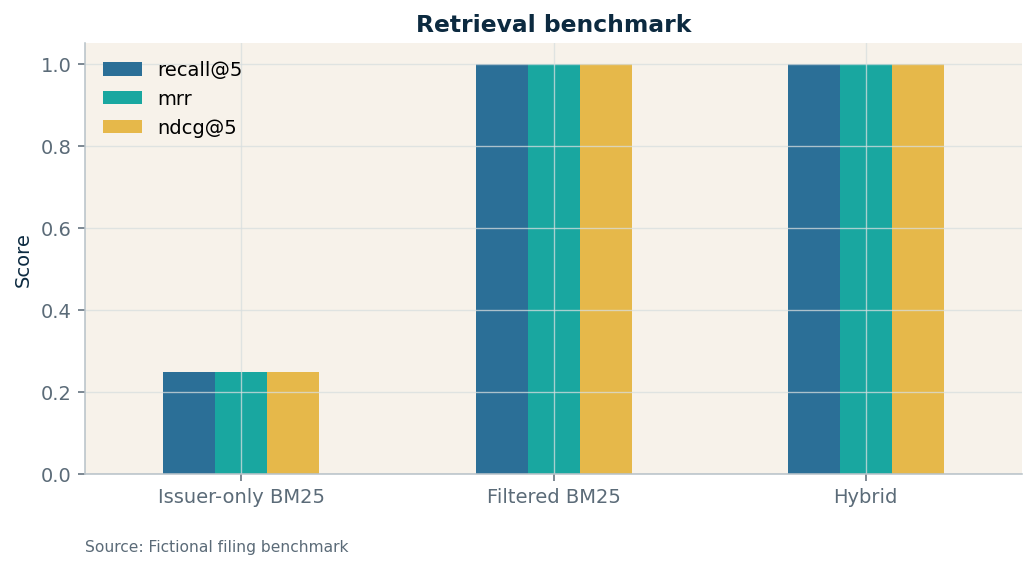

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
retrieval_table.plot(kind="bar", ax=ax, color=[COLORS["blue"], COLORS["teal"], COLORS["gold"]])
ax.set(title="Retrieval benchmark", ylabel="Score", ylim=(0, 1.05), xlabel="")
ax.tick_params(axis="x", rotation=0)
finish(ax, "Fictional filing benchmark")
plt.tight_layout()


## 3. Demonstrate the fail-closed time gate

A 2026Q1 filing exists in the corpus but was not available at the earlier decision time.
Directly admitting it raises an error.


In [7]:
past_decision = pd.Timestamp("2026-02-20T12:00:00Z").to_pydatetime()
future_document = next(
    d for d in documents if d.issuer == "ACME" and d.metadata["period"] == "2026Q1"
)
try:
    assert_documents_available([future_document], past_decision)
    leakage_result = "unexpected pass"
except TemporalLeakageError as exc:
    leakage_result = f"blocked: {exc}"
print(leakage_result)


blocked: Documents unavailable at decision time: filing-ACME-2026Q1-results


## 4. Claim-level faithfulness

Retrieval can be excellent while an answer invents a number. We score one supported and
one unsupported material claim against the same evidence.


In [8]:
results_question = next(q for q in questions if q["question_id"] == "q-ACME-results")
results_evidence = tuple(
    index.search(
        results_question["query"],
        k=3,
        decision_time=pd.Timestamp(results_question["decision_time"]).to_pydatetime(),
        issuer="ACME",
        section="results",
        period="2025Q4",
    )
)
supported = Claim(
    "claim-supported",
    "For 2025Q4, Acme Cloud Systems recorded revenue of $2,333.0 million with 6.6% year-over-year growth.",
)
unsupported = Claim(
    "claim-unsupported",
    "For 2025Q4, Acme Cloud Systems generated free cash flow of $999 million.",
)
faithfulness = pd.DataFrame(
    {
        "answer": ["supported template", "invented number"],
        "score": [
            faithfulness_score([EvidenceBundle(supported, results_evidence)]),
            faithfulness_score([EvidenceBundle(unsupported, results_evidence)]),
        ],
        "evidence_ids": [[e.evidence_id for e in results_evidence]] * 2,
    }
)
faithfulness


,answer,score,evidence_ids
0,supported template,1.0,[ev::filing-ACME-2025Q4-results]
1,invented number,0.0,[ev::filing-ACME-2025Q4-results]


## 5. End-to-end release gate


In [9]:
quality = {
    "recall_wilson_lower": hybrid_hit_low,
    "mrr": float(retrieval_table.loc["Hybrid", "mrr"]),
    "supported_faithfulness": float(faithfulness.iloc[0]["score"]),
    "future_document_block_rate": 1.0 if leakage_result.startswith("blocked") else 0.0,
}
released, checks = release_score(
    quality,
    {
        "recall_wilson_lower": ("min", 0.80),
        "mrr": ("min", 0.85),
        "supported_faithfulness": ("min", 0.95),
        "future_document_block_rate": ("min", 1.0),
    },
)
release_packet = {
    "metrics": quality,
    "checks": checks,
    "release": "PASS_TEACHING_BENCHMARK" if released else "HOLD",
    "benchmark_questions": len(questions),
    "uncertainty_note": (
        "Bootstrap intervals condition on these fictional questions; the Wilson "
        "hit-rate interval reflects the small benchmark size."
    ),
    "corpus_fingerprint": canonical_hash(
        [(d.document_id, d.available_at.isoformat()) for d in documents]
    ),
}
release_packet


{'benchmark_questions': 16,
 'checks': {'future_document_block_rate': True,
            'mrr': True,
            'recall_wilson_lower': True,
            'supported_faithfulness': True},
 'corpus_fingerprint': 'dcf9ab5558e3ec604b39af2fd16c0c1891b2ad6158c9e9d492f1ff3906bdd870',
 'metrics': {'future_document_block_rate': 1.0,
             'mrr': 1.0,
             'recall_wilson_lower': 0.8063923194655637,
             'supported_faithfulness': 1.0},
 'release': 'PASS_TEACHING_BENCHMARK',
 'uncertainty_note': 'Bootstrap intervals condition on these fictional questions; the Wilson '
                     'hit-rate interval reflects the small benchmark size.'}

## Takeaways

- Retrieval must filter by availability before ranking.
- Evidence identifiers are part of the output contract.
- Recall and nDCG do not measure whether the generated claim is supported.
- A RAG release gate should test retrieval, faithfulness, temporal integrity, and failure cases.

**Challenge:** add section-aware reranking and report metrics both overall and by section.
